<a href="https://colab.research.google.com/github/moonbang2/commerce/blob/%EB%AC%B8%EB%B3%91%EB%91%90/%EA%B3%A0%EA%B0%9D_%ED%96%89%EB%8F%99_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

고객 행동 분석

목적: 고객의 구매 행동에 영향을 주는 핵심 요인을 규명하고,
장바구니 전환률과 구매 전환률을 개선할 수 있는 구체적 기획 방향을 찾는다.



---
요인:성별 나이 도시, 멤버십 만족도, 할인여부,평점
결과:소비 비용 , 최근 구매

---
목표:장바구니 담기율 상승

구매 전환율 상승

가격·리뷰·멤버십 혜택에 따른 전환 영향도 수치화



In [1]:
# 라이브러리 불러오기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 읽어오기
df = pd.read_csv("/content/E-commerce Customer Behavior - Sheet1 (1).csv")
df

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied
...,...,...,...,...,...,...,...,...,...,...,...
345,446,Male,32,Miami,Silver,660.30,10,3.8,True,42,Unsatisfied
346,447,Female,36,Houston,Bronze,470.50,8,3.0,False,27,Neutral
347,448,Female,30,New York,Gold,1190.80,16,4.5,True,28,Satisfied
348,449,Male,34,Los Angeles,Silver,780.20,11,4.2,False,21,Neutral


In [4]:
print(df.head(),df.tail())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [11]:
# 정보 확인
print(df.shape)

print(df.info())
print("중복:",df.duplicated().sum())

(350, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None
중복: 0


데이터 처리
---
만족도 조사를 안한 경우: 응답을 안 한 것으로 판단하여 0으로 처리 , 삭제 처리  

In [12]:
# 만족도 조사 삭제 처리

df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               348 non-null    int64  
 1   Gender                    348 non-null    object 
 2   Age                       348 non-null    int64  
 3   City                      348 non-null    object 
 4   Membership Type           348 non-null    object 
 5   Total Spend               348 non-null    float64
 6   Items Purchased           348 non-null    int64  
 7   Average Rating            348 non-null    float64
 8   Discount Applied          348 non-null    bool   
 9   Days Since Last Purchase  348 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 30.2+ KB


주요 요인 파악

*   성별,나이
*   도시
*   멤버십
*   할인여부



성별

In [14]:
Gender = df['Gender'].value_counts().reset_index()
Gender

,Gender,count
0,Male,175
1,Female,173


from matplotlib import pyplot as plt
Gender['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
Gender.groupby('Gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
Gender['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(Gender['Gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(Gender, x='count', y='Gender', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

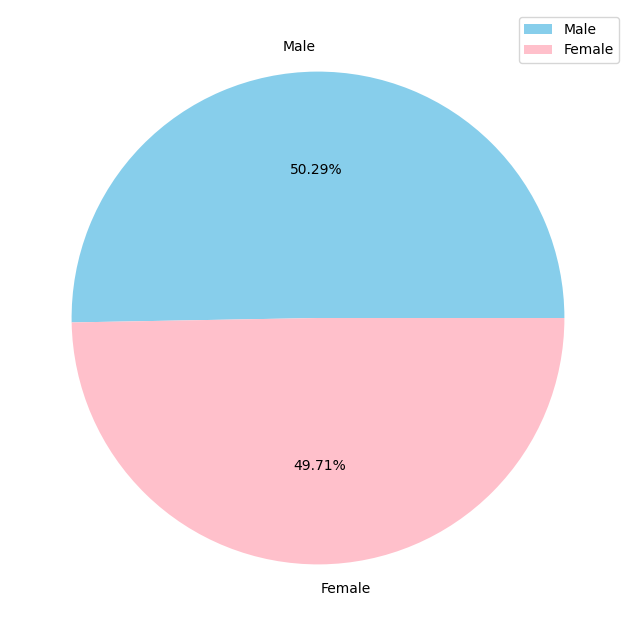

In [16]:
plt.figure(figsize=(8,8))
plt.pie(Gender['count'], colors=['skyblue', 'pink'],
        labels=Gender['Gender'],
        autopct='%1.2f%%'
       )
plt.legend()
plt.show()

In [17]:
GenderwithAge = df.groupby('Gender')['Age'].value_counts().reset_index()
GenderwithAge

,Gender,Age,count
0,Female,43,25
1,Female,30,24
2,Female,31,24
3,Female,36,24
4,Female,41,24
5,Female,37,22
6,Female,32,9
7,Female,38,9
8,Female,42,9
9,Female,29,2


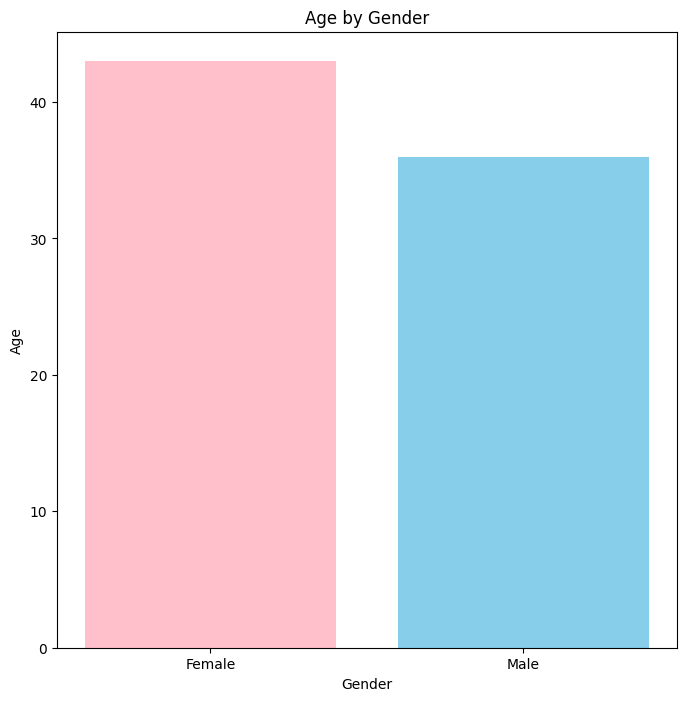

In [18]:
plt.figure(figsize=(8,8))
plt.bar(GenderwithAge['Gender'], GenderwithAge['Age'],
        color=['pink', 'skyblue'],
       )
plt.xlabel('Gender')
plt.ylabel('Age')
plt.title('Age by Gender')
plt.show()

In [19]:
GenderWithMembershiptype = df[['Gender','Membership Type']].value_counts().reset_index()
GenderWithMembershiptype

,Gender,Membership Type,count
0,Male,Silver,116
1,Female,Bronze,114
2,Male,Gold,59
3,Female,Gold,58
4,Female,Silver,1


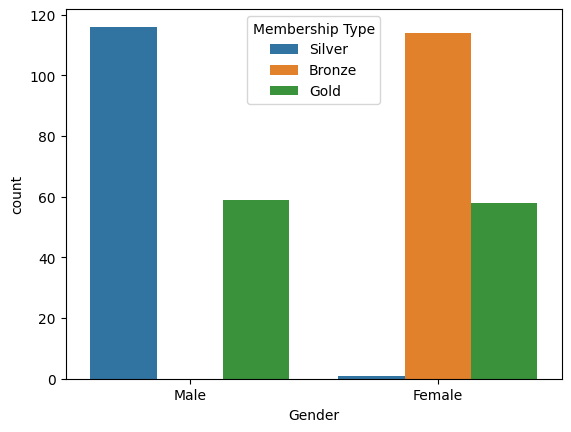

In [20]:
sns.barplot(data=GenderWithMembershiptype, x='Gender', y='count', hue='Membership Type')
plt.show()

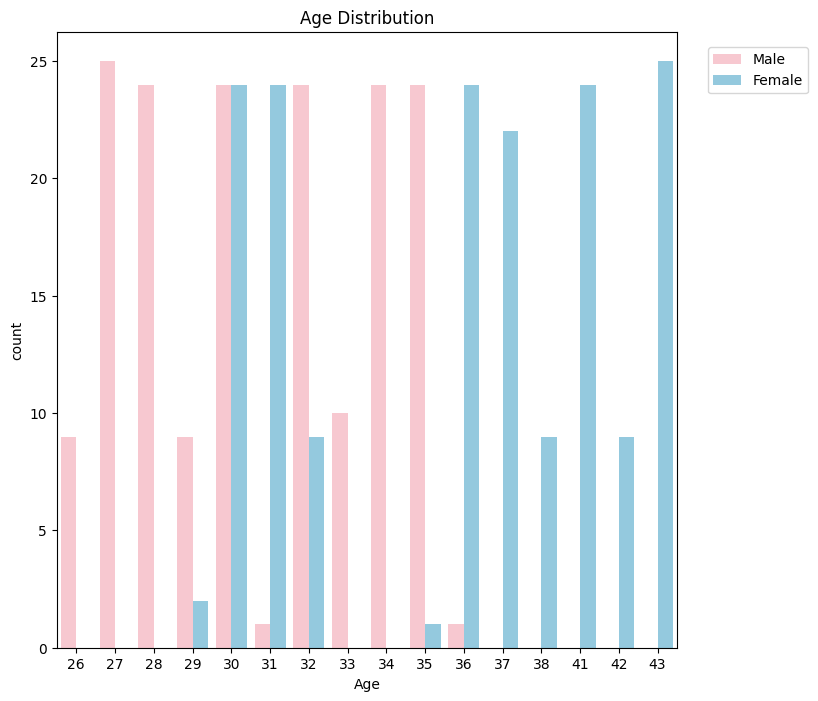

In [21]:
gender_age_data = df[['Gender', 'Age']].value_counts().reset_index().sort_values(ascending=False, by='count')

plt.figure(figsize=(8, 8))
sns.barplot(data=gender_age_data, x='Age', y='count', hue='Gender', palette=['pink', 'skyblue'])
plt.title("Age Distribution")
plt.legend(loc=(1.05,0.9))
plt.show()

나이

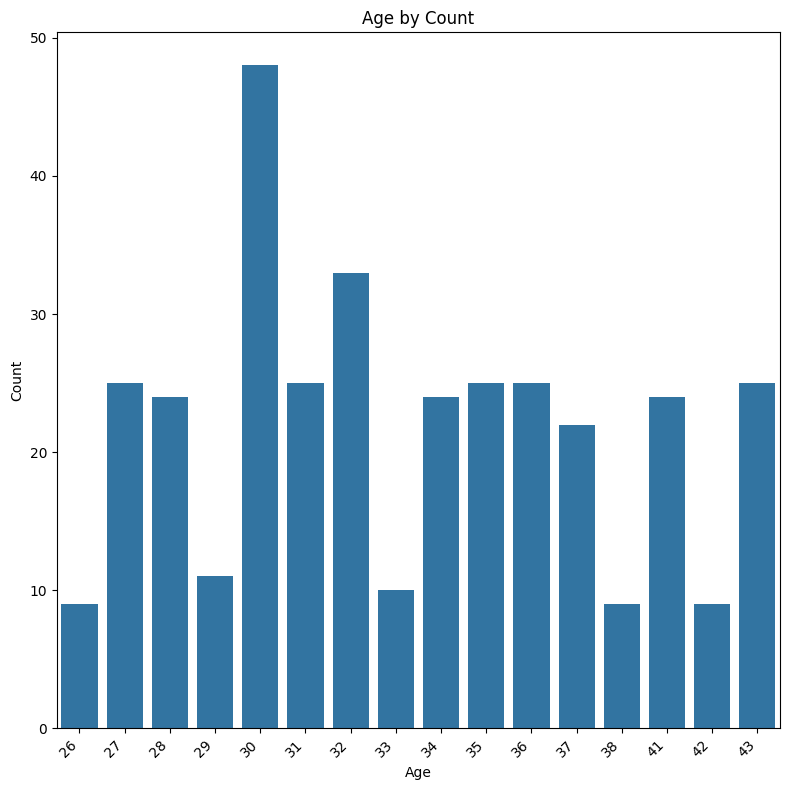

In [22]:
age_data = df['Age'].value_counts().reset_index()
plt.figure(figsize=(8, 8))
sns.barplot(data=age_data,x='Age', y='count')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate the labels for better readability
plt.title('Age by Count')
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

도시

In [24]:
city = df['City'].value_counts().reset_index()
city

,City,count
0,New York,59
1,Los Angeles,59
2,Chicago,58
3,San Francisco,58
4,Miami,58
5,Houston,56


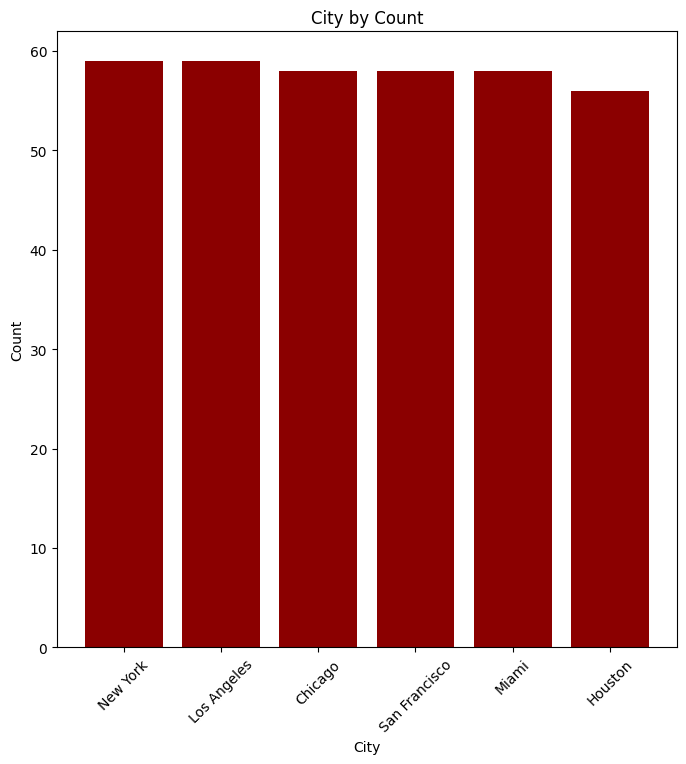

In [28]:
xticks = city['City']
plt.figure(figsize=(8,8))
plt.bar(city['City'], city['count'],
        color='darkred',
       )
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(xticks,rotation=45)
plt.title('City by Count')
plt.show()

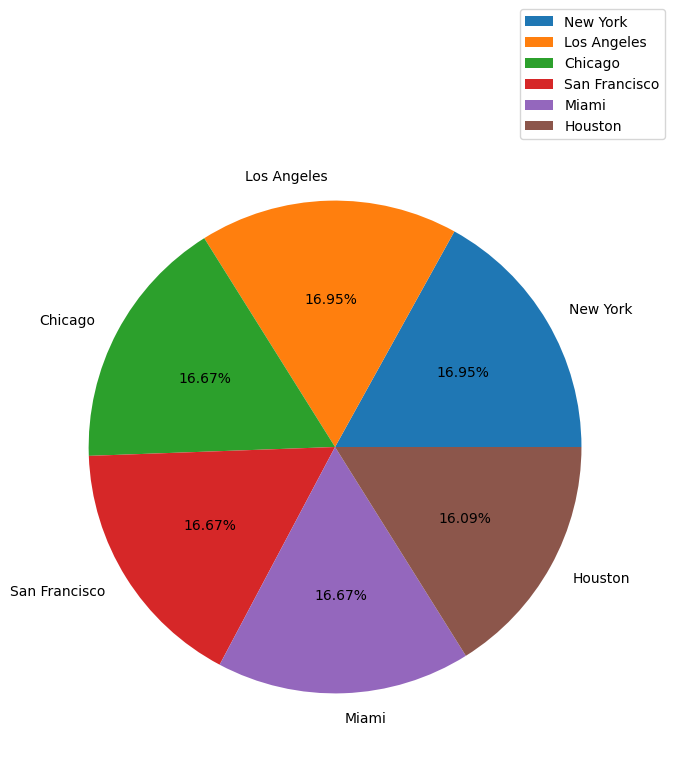

In [30]:
plt.figure(figsize=(8,8))
plt.pie(city['count'],
        labels= city['City'],
        autopct='%1.2f%%'
       )
plt.legend(loc=(0.8,1))
plt.show()

멤버십

In [31]:
MembershipType = df['Membership Type'].value_counts().reset_index()
MembershipType

,Membership Type,count
0,Gold,117
1,Silver,117
2,Bronze,114


/tmp/ipython-input-808649454.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=MembershipType, x='Membership Type', y='count' ,palette=['darkred'])
/tmp/ipython-input-808649454.py:1: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=MembershipType, x='Membership Type', y='count' ,palette=['darkred'])
/tmp/ipython-input-808649454.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.1,0.8))


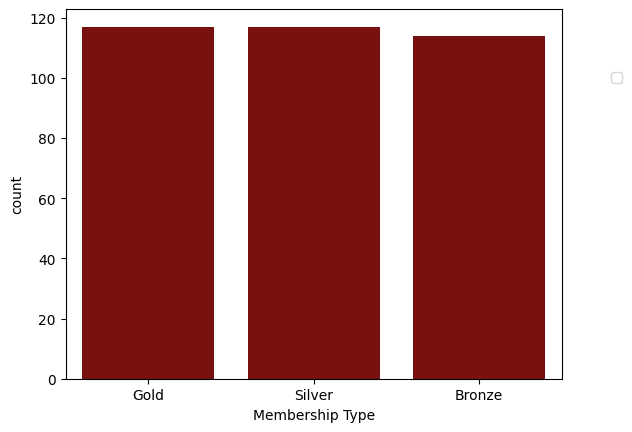

In [32]:
sns.barplot(data=MembershipType, x='Membership Type', y='count' ,palette=['darkred'])
plt.legend(loc=(1.1,0.8))
plt.show()

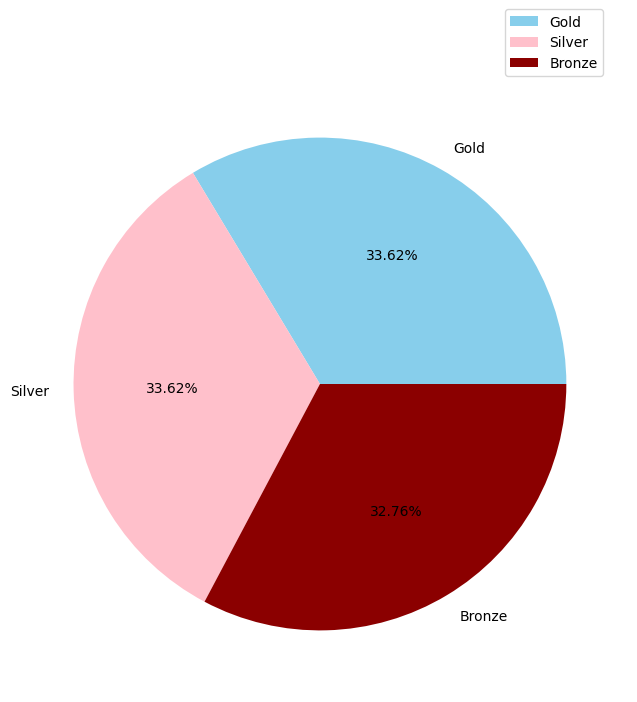

In [34]:
plt.figure(figsize=(8,8))
plt.pie(MembershipType['count'], colors=['skyblue', 'pink','darkred'],
        labels= MembershipType['Membership Type'],
        autopct='%1.2f%%'
       )
plt.legend(loc=(0.8,1))
plt.show()

할인 여부

In [37]:
discount = df['Discount Applied'].value_counts().reset_index()
discount

,Discount Applied,count
0,True,175
1,False,173


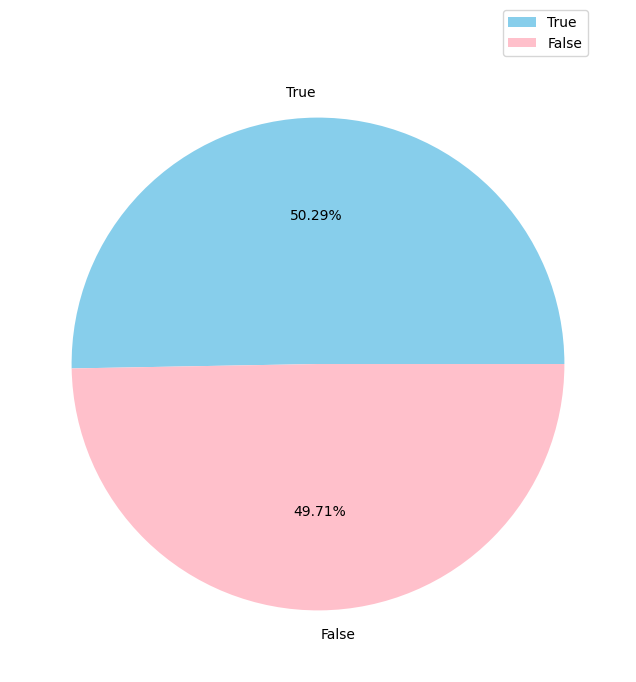

In [38]:
plt.figure(figsize=(8,8))
plt.pie(discount['count'], colors=['skyblue', 'pink'],
        labels= discount['Discount Applied'],
        autopct='%1.2f%%'
       )
plt.legend(loc=(0.8,1))
plt.show()

 결과 요인 파악



*   성별,나이 소비
*   멤버십
* 할인여부 소비


In [40]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [49]:
gender_spent = df.groupby(['Gender','Age']).agg({'Total Spend': 'mean','Days Since Last Purchase':'mean','Items Purchased':'mean','Average Rating':'mean'}).reset_index().sort_values(by='Total Spend', ascending=False)
gender_spent

,Gender,Age,Total Spend,Days Since Last Purchase,Items Purchased,Average Rating
13,Male,28,1492.183333,10.083333,21.000000,4.895833
15,Male,30,1462.158333,12.708333,19.791667,4.762500
21,Male,36,1420.800000,11.000000,19.000000,4.600000
14,Male,29,1371.311111,10.000000,18.000000,4.722222
16,Male,31,1210.600000,18.000000,17.000000,4.800000
1,Female,30,1189.133333,21.541667,16.000000,4.591667
3,Female,32,1162.522222,22.666667,14.000000,4.444444
2,Female,31,1141.850000,28.625000,15.000000,4.520833
0,Female,29,925.300000,37.500000,14.000000,4.300000
18,Male,33,820.640000,14.900000,12.600000,4.210000


Text(0.5, 1.0, 'Average Rating by Gender')

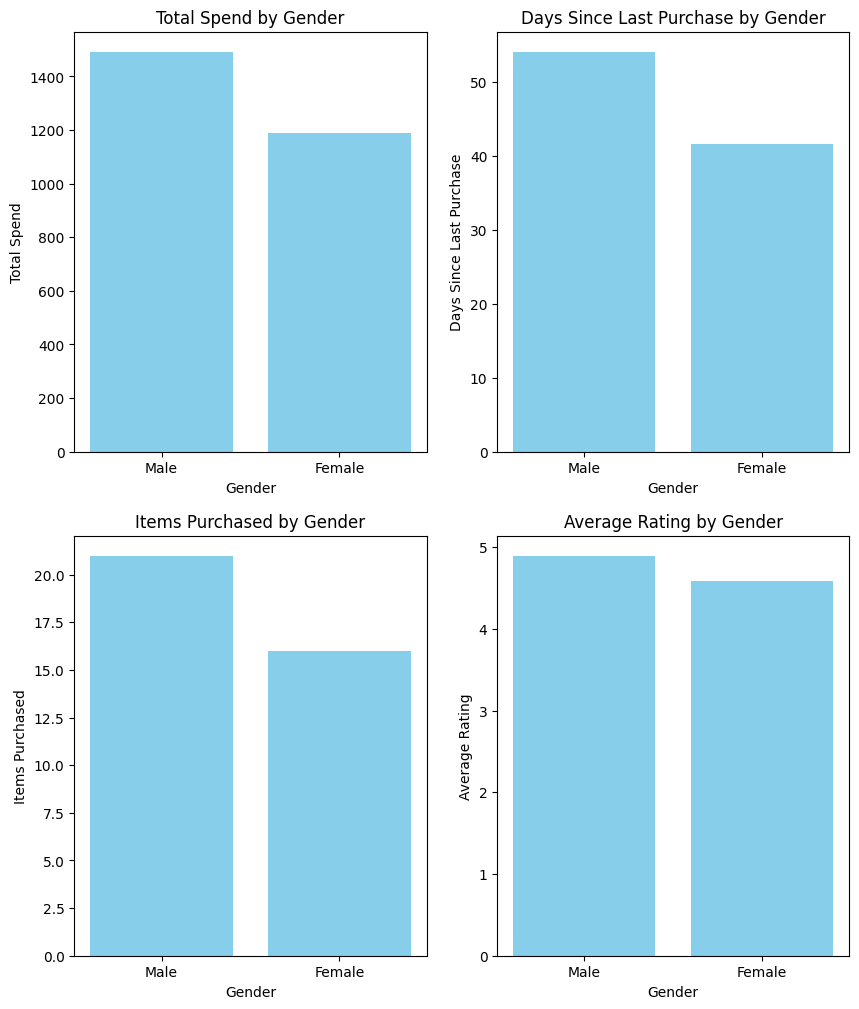

In [59]:
plt.figure(figsize=(10,12))
plt.subplot(2,2,1)
plt.bar(gender_spent['Gender'], gender_spent['Total Spend'], color='skyblue')
plt.xlabel('Gender')
plt.ylabel('Total Spend')
plt.title('Total Spend by Gender')
plt.subplot(2,2,2)
plt.bar(gender_spent['Gender'], gender_spent['Days Since Last Purchase'], color='skyblue')
plt.xlabel('Gender')
plt.ylabel('Days Since Last Purchase')
plt.title('Days Since Last Purchase by Gender')
plt.subplot(2,2,3)
plt.bar(gender_spent['Gender'], gender_spent['Items Purchased'], color='skyblue')
plt.xlabel('Gender')
plt.ylabel('Items Purchased')
plt.title('Items Purchased by Gender')
plt.subplot(2,2,4)
plt.bar(gender_spent['Gender'], gender_spent['Average Rating'], color='skyblue')
plt.xlabel('Gender')
plt.ylabel('Average Rating')
plt.title('Average Rating by Gender')

Text(0.5, 1.0, 'Average Rating by Age')

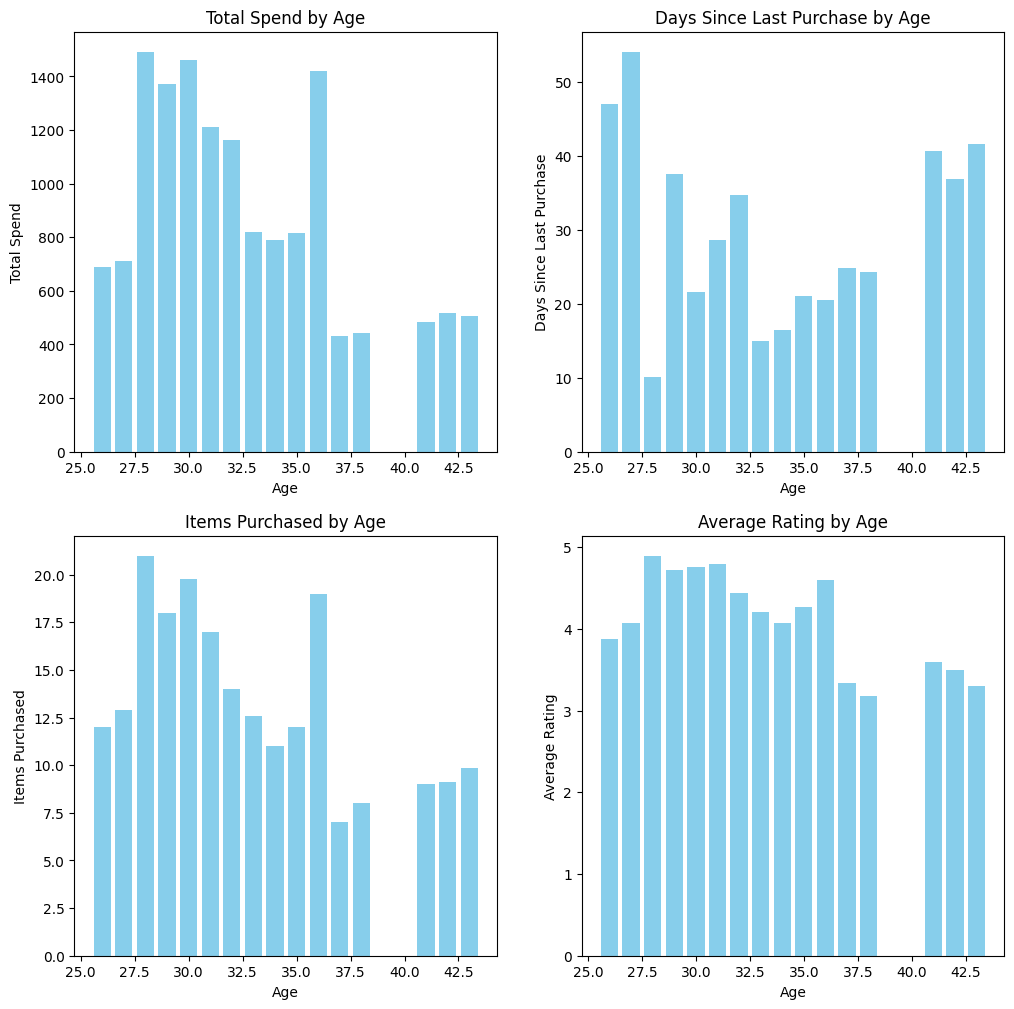

In [62]:
plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
plt.bar(gender_spent['Age'], gender_spent['Total Spend'], color='skyblue')
plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Total Spend by Age')
plt.subplot(2,2,2)
plt.bar(gender_spent['Age'], gender_spent['Days Since Last Purchase'], color='skyblue')
plt.xlabel('Age')
plt.ylabel('Days Since Last Purchase')
plt.title('Days Since Last Purchase by Age')
plt.subplot(2,2,3)
plt.bar(gender_spent['Age'], gender_spent['Items Purchased'], color='skyblue')
plt.xlabel('Age')
plt.ylabel('Items Purchased')
plt.title('Items Purchased by Age')
plt.subplot(2,2,4)
plt.bar(gender_spent['Age'], gender_spent['Average Rating'], color='skyblue')
plt.xlabel('Age')
plt.ylabel('Average Rating')
plt.title('Average Rating by Age')

멥버십

In [64]:
member_spent = df.groupby('Membership Type').agg({'Total Spend': 'mean','Days Since Last Purchase':'mean','Items Purchased':'mean','Average Rating':'mean'}).reset_index().sort_values(by='Total Spend', ascending=False)
member_spent

,Membership Type,Total Spend,Days Since Last Purchase,Items Purchased,Average Rating
1,Gold,1311.144444,17.940171,17.615385,4.675214
2,Silver,748.432479,30.256410,11.658120,4.051282
0,Bronze,474.223684,31.780702,8.517544,3.326316


Text(0.5, 1.0, 'Average Rating by Membership Type')

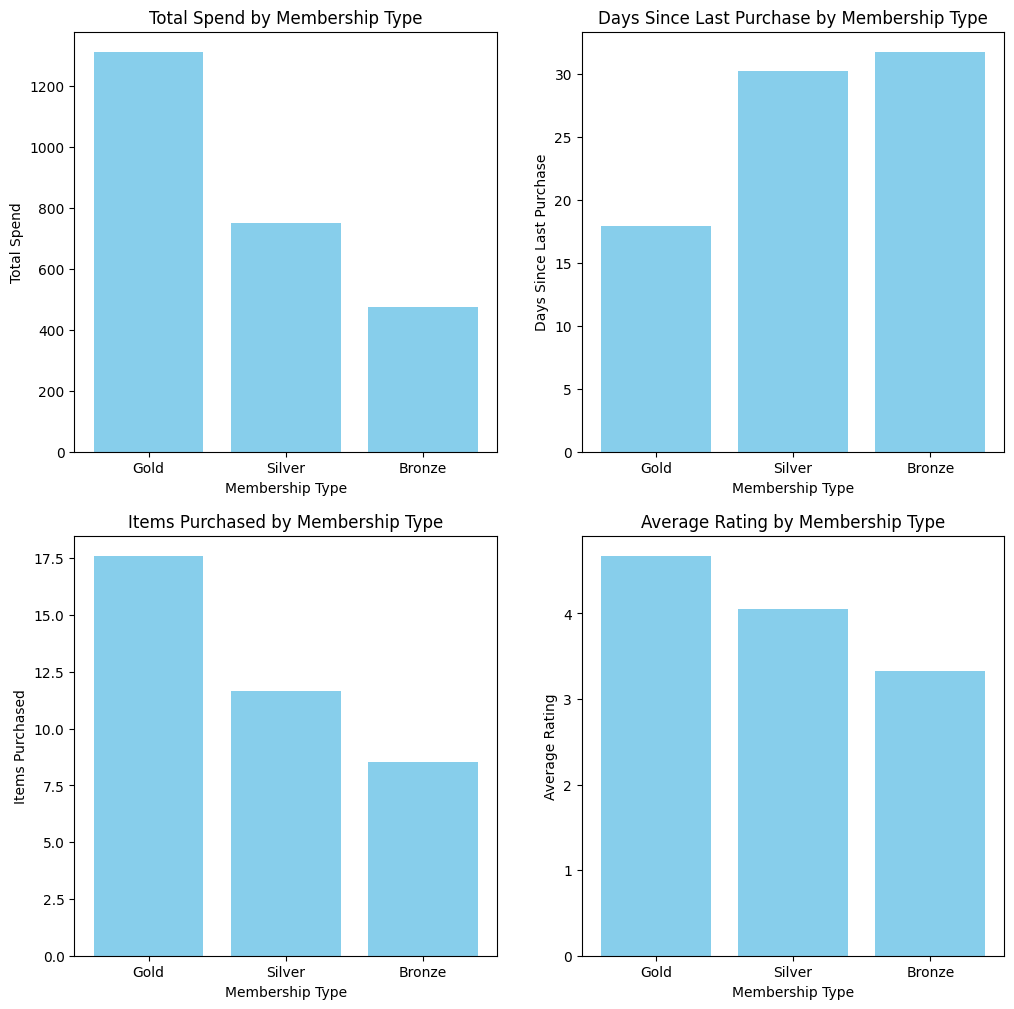

In [65]:
plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
plt.bar(member_spent['Membership Type'], member_spent['Total Spend'], color='skyblue')
plt.xlabel('Membership Type')
plt.ylabel('Total Spend')
plt.title('Total Spend by Membership Type')
plt.subplot(2,2,2)
plt.bar(member_spent['Membership Type'], member_spent['Days Since Last Purchase'], color='skyblue')
plt.xlabel('Membership Type')
plt.ylabel('Days Since Last Purchase')
plt.title('Days Since Last Purchase by Membership Type')
plt.subplot(2,2,3)
plt.bar(member_spent['Membership Type'], member_spent['Items Purchased'], color='skyblue')
plt.xlabel('Membership Type')
plt.ylabel('Items Purchased')
plt.title('Items Purchased by Membership Type')
plt.subplot(2,2,4)
plt.bar(member_spent['Membership Type'], member_spent['Average Rating'], color='skyblue')
plt.xlabel('Membership Type')
plt.ylabel('Average Rating')
plt.title('Average Rating by Membership Type')

멤버십 GOlD > Silver > Bronze 순으로 구매 소비가 들러나고 있다



---
추가 분석: 멤버십 해택 분석
나이 멤버십 가입 수,
해택 적용 (할인)


In [81]:
age_member_Applied = df.groupby('Age')['Membership Type'].value_counts().reset_index()
age_member_Applied

,Age,Membership Type,count
0,26,Silver,9
1,27,Silver,25
2,28,Gold,24
3,29,Gold,10
4,29,Silver,1
5,30,Gold,48
6,31,Gold,25
7,32,Silver,24
8,32,Gold,9
9,33,Silver,10


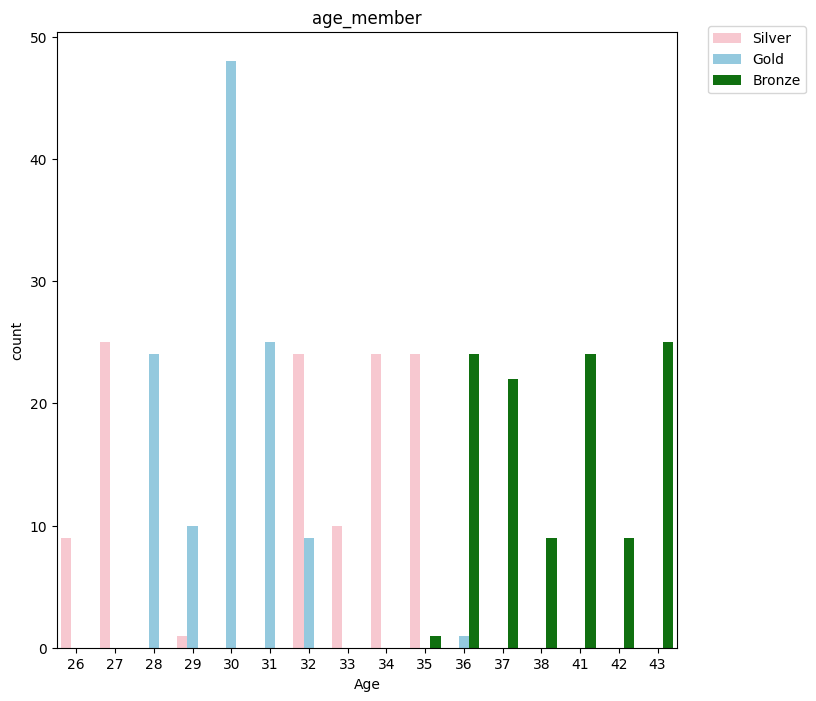

In [87]:
plt.figure(figsize=(8, 8))
sns.barplot(data=age_member_Applied, x='Age', y='count', hue='Membership Type', palette=['pink', 'skyblue','green'])
plt.title("age_member")
plt.legend(loc=(1.05,0.9))
plt.show()

In [82]:
# 멤버십 별 혜택 적용 할인
member_Applied = df.groupby('Membership Type')['Discount Applied'].value_counts().reset_index()
member_Applied

,Membership Type,Discount Applied,count
0,Bronze,True,58
1,Bronze,False,56
2,Gold,True,59
3,Gold,False,58
4,Silver,False,59
5,Silver,True,58


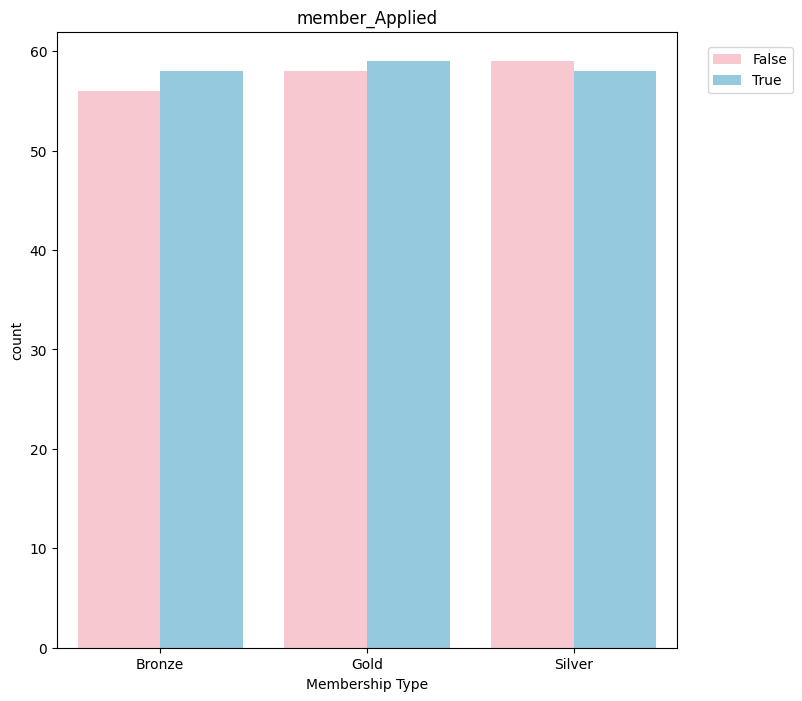

In [88]:
plt.figure(figsize=(8, 8))
sns.barplot(data=member_Applied, x='Membership Type', y='count', hue='Discount Applied', palette=['pink', 'skyblue'])
plt.title("member_Applied")
plt.legend(loc=(1.05,0.9))
plt.show()

만족도

In [76]:
SatistactionLevelandaveragespend = df.groupby('Satisfaction Level')['Total Spend'].mean().reset_index()
SatistactionLevelandaveragespend

,Satisfaction Level,Total Spend
0,Neutral,616.414019
1,Satisfied,1280.319200
2,Unsatisfied,595.136207


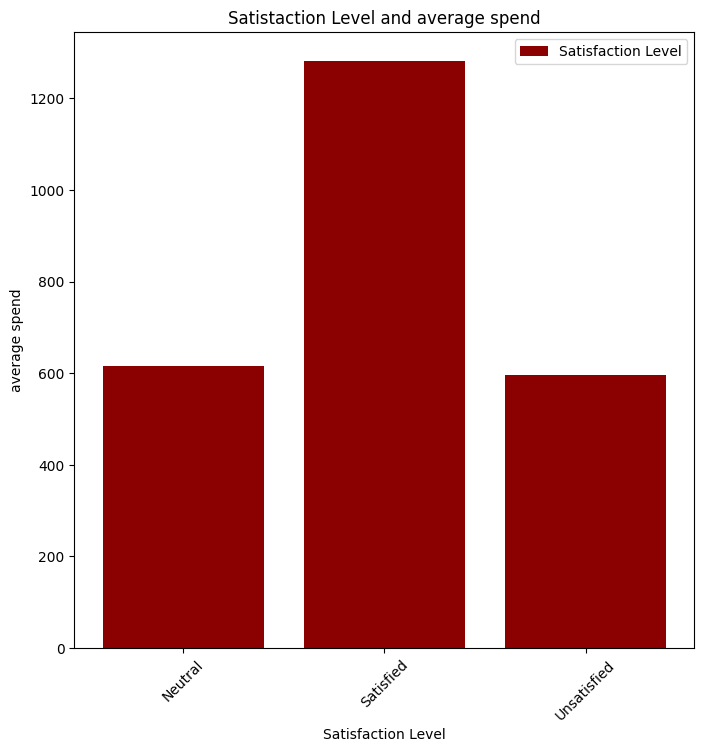

In [77]:
xticks = SatistactionLevelandaveragespend['Satisfaction Level']
plt.figure(figsize=(8,8))
plt.bar(SatistactionLevelandaveragespend['Satisfaction Level'], SatistactionLevelandaveragespend['Total Spend'], label='Satisfaction Level',color='darkred')
plt.legend(loc='upper right')  # Adjust the location of the legend as needed
plt.xlabel('Satisfaction Level')
plt.ylabel('average spend')
plt.xticks(xticks,rotation=45)
plt.title('Satistaction Level and average spend')
plt.show()

멤버십 만족 레벨

In [83]:
# 멤버십 만족 레벨
member_satisfaction = df.groupby('Membership Type')['Satisfaction Level'].value_counts().reset_index()
member_satisfaction

,Membership Type,Satisfaction Level,count
0,Bronze,Unsatisfied,58
1,Bronze,Neutral,56
2,Gold,Satisfied,117
3,Silver,Unsatisfied,58
4,Silver,Neutral,51
5,Silver,Satisfied,8


from matplotlib import pyplot as plt
member_satisfaction['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
member_satisfaction.groupby('Membership Type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
member_satisfaction.groupby('Satisfaction Level').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
member_satisfaction['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Satisfaction Level'].value_counts()
    for x_label, grp in member_satisfaction.groupby('Membership Type')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Membership Type')
_ = plt.ylabel('Satisfaction Level')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(member_satisfaction['Membership Type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(member_satisfaction, x='count', y='Membership Type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(member_satisfaction['Satisfaction Level'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(member_satisfaction, x='count', y='Satisfaction Level', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

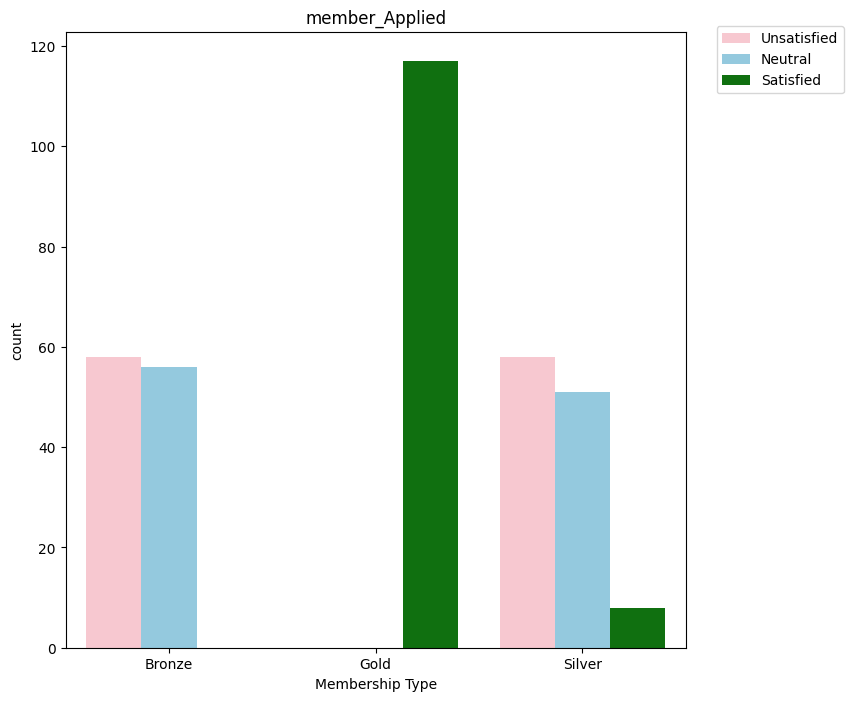

In [90]:
plt.figure(figsize=(8, 8))
sns.barplot(data=member_satisfaction, x='Membership Type', y='count', hue='Satisfaction Level', palette=['pink', 'skyblue','Green'])
plt.title("member_Applied")
plt.legend(loc=(1.05,0.9))
plt.show()

할인

In [78]:
DiscountApplied = df['Discount Applied'].value_counts().reset_index()
DiscountApplied

,Discount Applied,count
0,True,175
1,False,173


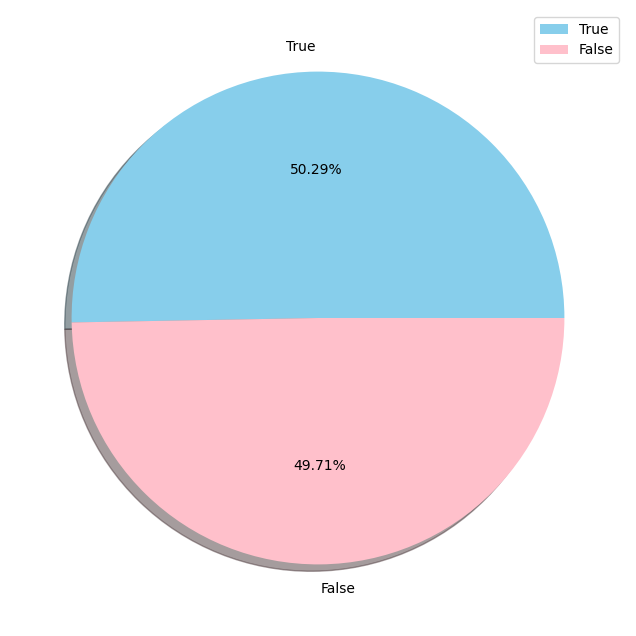

In [79]:
plt.figure(figsize=(8,8))
plt.pie(DiscountApplied['count'], colors=['skyblue', 'pink'],
        shadow=True,labels=DiscountApplied['Discount Applied'],
        autopct='%1.2f%%'
       )
plt.legend()
plt.show()

In [80]:
DiscountApplied = df.groupby('Gender')['Discount Applied'].value_counts().reset_index()
DiscountApplied

,Gender,Discount Applied,count
0,Female,True,117
1,Female,False,56
2,Male,False,117
3,Male,True,58


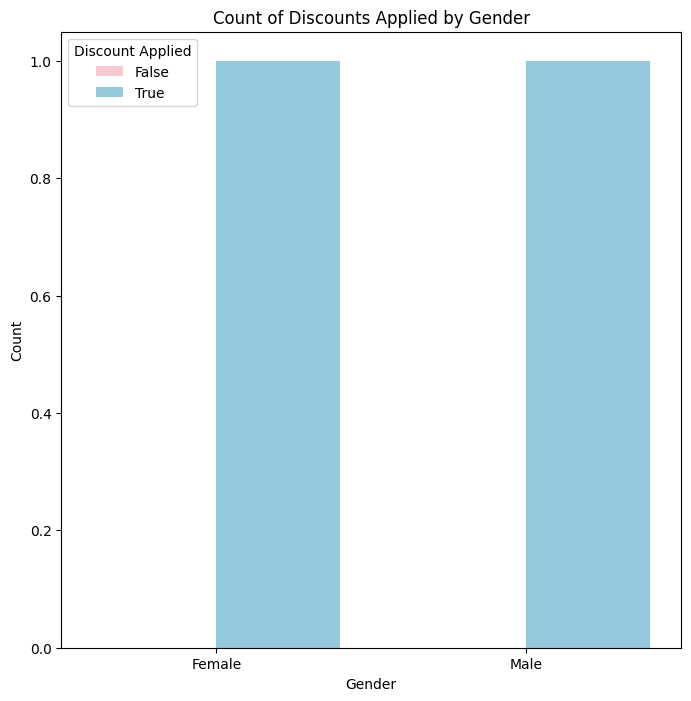

In [91]:
plt.figure(figsize=(8, 8))
sns.barplot(data=DiscountApplied, x='Gender', y='Discount Applied', hue='Discount Applied', palette=['pink', 'skyblue'])

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Count of Discounts Applied by Gender')
plt.legend(title='Discount Applied')
plt.show()

만족 평점

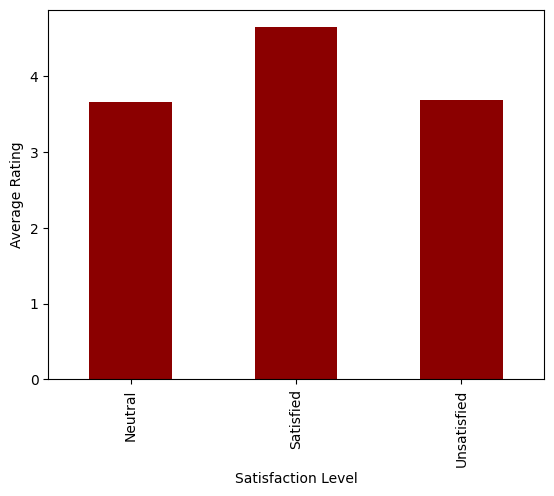

In [92]:
satisfaction_rating = df.groupby('Satisfaction Level')['Average Rating'].mean()
satisfaction_rating.plot.bar(color='darkred')
plt.ylabel('Average Rating')
plt.show()